# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

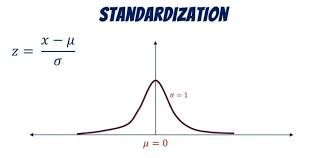


Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

Open the file in read mode

In [ ]:
raw = np.genfromtxt('co2 Emission Africa.csv', delimiter=',', dtype=str, encoding='utf-8')
header = raw[0]
data = raw[1:]

print('Data shape:', data.shape)
print('Header:', header)

**Explanation** The file loads as **1,134 rows × 20 columns**: 54 countries × 21 years (2000–2020). There are 5 sub-regions: Eastern, Middle, Northern, Southern and Western Africa. The header shows three kinds of column:
- **Identifiers:** Country, Sub-Region, Code, Year.
- **Socio-economic indicators:** population, GDP per capita, area.
- **CO₂ emissions** broken down by sector.

np.genfromtxt with dtype=str works here because no field contains a quoted comma.

Check for missing values

In [ ]:
missing = ['', 'NA', 'N/A']
for j, name in enumerate(header):
    n_missing = np.isin(data[:, j], missing).sum()
    if n_missing > 0:
        print(f'{name} has {n_missing} missing values')

In [ ]:
#find the numeric columns
def numeric_column(column):
    values = column[~np.isin(column, missing)]
    try:
        values.astype(float)
        return True
    except ValueError:
        return False

numeric_idx = [j for j in range(len(header)) if numeric_column(data[:, j])]
non_numeric = [header[j] for j in range(len(header)) if j not in numeric_idx]

print('Numeric columns:', len(numeric_idx))
print('Non-numeric (kept as labels):', non_numeric)

**Explanation:** The function tries to convert each column's non-missing values to float. **17 columns are numeric** and **3 are non-numeric**:
- Country has 54 nmes.
- Sub-Region` has 5 categories.
- Code is the 3-etter ISO country code.

These are identified here and handled in the encoding step below.

In [ ]:
missing_frac = np.isin(data, missing).mean(axis=0)
MAX_MISSING = 0.5

keep_idx = [j for j in numeric_idx if missing_frac[j] <= MAX_MISSING]
dropped = [(header[j], round(missing_frac[j] * 100, 1)) for j in numeric_idx if j not in keep_idx]

print('Dropped for too many missing values (name, % missing):', dropped)

**Explanation:** A feature that is more than 50% missing cannot be imputed reliably, because most of its values would be invented. **Fugitive Emissions** (70.9% missing) is therefore dropped as a column. Every other numeric column is below 6% missing, so those columns are kept and imputed.

In [ ]:
# Year is a time index, not a measurement.
# The three totals are sums of other columns, so they would duplicate information in PCA.
exclude = ['Year',
            'Total CO2 Emission including LUCF (Mt)',
            'Total CO2 Emission excluding LUCF (Mt)',
            'Energy (Mt)']

feature_idx = [j for j in keep_idx if header[j] not in exclude]
feature_names = [str(header[j]) for j in feature_idx]

def to_float(v):
    return np.nan if v in missing else float(v)

X = np.array([[to_float(v) for v in row] for row in data[:, feature_idx]])

countries = data[:, 0]
subregions = data[:, 1]
years = data[:, 3]

print('Features used:', len(feature_names))
print(feature_names)
print('Feature matrix shape:', X.shape)
print('NaN per feature:', np.isnan(X).sum(axis=0))
print('Rows with any NaN:', np.isnan(X).any(axis=1).sum())

**Explanation:** Besides Fugitive Emissions, four more numeric columns are excluded:
- Year is a time index, not a characteristic of a country.
- Energy is the sum of the energy sectors (transport, electricity, manufacturing, buildings, other fuel).
- Total CO2 excluding LUCF is Energy plus Industrial Processes.
- Total CO2 including LUCF additionally adds Land-Use Change.

Keeping the totals would count the same emissions twice, and PCA would treat that artificial correlation as real structure. That leaves **12 features**: 4 socio-economic (population, 2 × GDP per capita, area) and 8 emission sectors. There are still **121 NaNs spread over 101 rows**.

#### Handling the remaining missing values
The missing values are not all the same kind, so they are handled in three ways:

| Case | Rows affected | Treatment | Why |
|---|---|---|---|
| **South Sudan, 2000–2011** | 12 rows | **Drop the rows** | The country only became independent in 2011. These rows have no emissions data at all, so any value we filled in would be invented |
| A country has *some* values for a feature | e.g. Botswana's Industrial Processes 2000–2008, Somalia's GDP 2000–2012 | **The country's own median** for that feature | A country's economy and emissions change slowly, so its own median is far more realistic than a continental average. The median is robust to outlier years |
| A country has *no* values for a feature | Eritrea's GDP PPP, Somalia's Industrial Processes | **The median of its sub-region in the same year** | Neighbouring economies in the same year are the closest available comparison |

Dropping every row with a NaN (the simplest option) would throw away 101 rows (9% of the data). It would also delete **every year** for Eritrea and Somalia, removing two countries from the analysis.

In [ ]:
not_yet_independent = (countries == 'South Sudan') & (years.astype(int) < 2012)

X_clean = X[~not_yet_independent].copy()
countries_clean = countries[~not_yet_independent]
subregions_clean = subregions[~not_yet_independent]
years_clean = years[~not_yet_independent].astype(int)

print('Rows dropped (South Sudan before independence):', not_yet_independent.sum())
print('Before:', X.shape, ' After:', X_clean.shape)
print('NaN still to impute:', np.isnan(X_clean).sum())

In [ ]:
X_original = X_clean.copy()  # look up medians in the original values only, never in imputed ones
filled_country, filled_region = 0, 0
for j in range(X_clean.shape[1]):
    for i in np.where(np.isnan(X_original[:, j]))[0]:
        own = X_original[countries_clean == countries_clean[i], j]
        if (~np.isnan(own)).any():
            X_clean[i, j] = np.nanmedian(own)
            filled_country += 1
        else:
            peers = (subregions_clean == subregions_clean[i]) & (years_clean == years_clean[i])
            X_clean[i, j] = np.nanmedian(X_original[peers, j])
            filled_region += 1

print('Filled with country median         :', filled_country)
print('Filled with sub-region/year median :', filled_region)
print('NaN remaining                      :', np.isnan(X_clean).sum())
print('Final shape                        :', X_clean.shape)

**Explanation:** All 121 remaining NaNs are resolved and the dataset has **1,122 complete rows**.
- **79 values** were filled with the country's own median. For example, Somalia's GDP for 2000–2012 is filled from its 2013–2020 values.
- **42 values** had no data for that country at all (Eritrea's GDP PPP and Somalia's Industrial Processes, 21 years each). These were filled with the sub-region's median for the same year.

The medians are always taken from the **original** values, never from previously imputed ones. This way every Eritrea year gets its own regional estimate instead of copying the first year's value.

#### Encoding the non-numeric columns
- **Sub-Region** (5 categories) is **one-hot encoded** into 5 binary columns. We do not add these dummies to the PCA features. Binary 0/1 columns do not have the continuous variance structure PCA assumes, and they would dominate a component on their own. Instead, the encoded region is used to **colour the plots and test whether PCA recovers regional groupings** from the numeric data alone.
- **Country** (54 categories) and **Code** (the ISO code, which duplicates Country) are identifiers. One-hot encoding them would add 54 sparse columns that describe *which* country a row is, not *how* it behaves, so they are kept only as labels.

In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
standardized_data = None  # Do not use sklearn
standardized_data[:5]  # Display the first few rows of standardized data

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = None  # Calculate covariance matrix
cov_matrix

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = None  # Perform eigendecomposition
eigenvalues, eigenvectors

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = None  # Sort eigenvalues in descending order
sorted_eigenvectors = None  # Sort eigenvectors accordingly
sorted_eigenvectors

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
num_components = None  # Decide on the number of principal components to keep
reduced_data = None  # Project data onto the principal components
reduced_data[:5]

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

In [ ]:
# Step 8: Visualize Before and After PCA


# Plot original data (first two features for simplicity)


# Plot reduced data after PCA


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?
